## 📚 1. Importación de Librerías

In [1]:
# Librerías estándar
import json
import warnings
from pathlib import Path

# Manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)

# NLP - BERT Embeddings
from sentence_transformers import SentenceTransformer

# Serialización
import joblib

# Utilidades locales
from utils import (
    cargar_dataset, generar_dataset_sintetico, preparar_datos,
    limpiar_texto, evaluar_modelo, plot_confusion_matrix,
    plot_metricas_por_clase, plot_distribucion_clases,
    guardar_modelo, predecir_clase, mostrar_prediccion,
    CLASES_PODER, CLASE_DESCRIPCIONES
)

# Configuración
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 100)

# Semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Librerías importadas correctamente")

c:\Users\c0d06h6\AppData\Local\anaconda3\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


✅ Librerías importadas correctamente


## 📂 2. Carga y Exploración de Datos

In [2]:
# Cargar el dataset de personajes
df = cargar_dataset()

print(f"📊 Dataset cargado: {len(df)} personajes")
print(f"\n📋 Columnas: {df.columns.tolist()}")
print(f"\n🎯 Clases de poder: {df['clase'].unique().tolist()}")

2025-12-22 11:10:46,632 - INFO - Dataset cargado: 87 personajes


📊 Dataset cargado: 87 personajes

📋 Columnas: ['nombre', 'descripcion', 'clase']

🎯 Clases de poder: ['Taijutsu', 'Ninjutsu', 'Genjutsu', 'Kekkai Genkai']


In [3]:
# Vista previa del dataset
print("\n🔍 Primeras 5 filas del dataset:")
df.head()


🔍 Primeras 5 filas del dataset:


,nombre,descripcion,clase
0,Rock Lee,Especialista absoluto en combate cuerpo a cuerpo. Domina las técnicas del Goken (Puño Fuerte) y ...,Taijutsu
1,Might Guy,Maestro de artes marciales y mentor de taijutsu. Puede abrir las Ocho Puertas y utilizar técnica...,Taijutsu
2,Neji Hyuga,"Experto en el Juken (Puño Suave), un estilo de taijutsu que ataca los puntos de chakra del enemi...",Taijutsu
3,Hinata Hyuga,Usuaria del estilo de combate Juken heredado del clan Hyuga. Especialista en golpes precisos a l...,Taijutsu
4,Sakura Haruno,Ninja médico con fuerza sobrehumana. Concentra chakra en sus puños para crear golpes devastadore...,Taijutsu


In [4]:
# Estadísticas descriptivas
print("\n📈 Estadísticas del dataset:")
print(f"   - Total de personajes: {len(df)}")
print(f"   - Clases únicas: {df['clase'].nunique()}")
print(f"   - Longitud promedio de descripción: {df['descripcion'].str.len().mean():.0f} caracteres")
print(f"   - Longitud mínima: {df['descripcion'].str.len().min()} caracteres")
print(f"   - Longitud máxima: {df['descripcion'].str.len().max()} caracteres")


📈 Estadísticas del dataset:
   - Total de personajes: 87
   - Clases únicas: 4
   - Longitud promedio de descripción: 158 caracteres
   - Longitud mínima: 127 caracteres
   - Longitud máxima: 281 caracteres


In [5]:
# Distribución de clases
print("\n📊 Distribución de clases:")
distribucion = df['clase'].value_counts()
for clase, count in distribucion.items():
    porcentaje = count / len(df) * 100
    print(f"   {clase}: {count} ({porcentaje:.1f}%)")


📊 Distribución de clases:
   Kekkai Genkai: 28 (32.2%)
   Ninjutsu: 25 (28.7%)
   Taijutsu: 20 (23.0%)
   Genjutsu: 14 (16.1%)


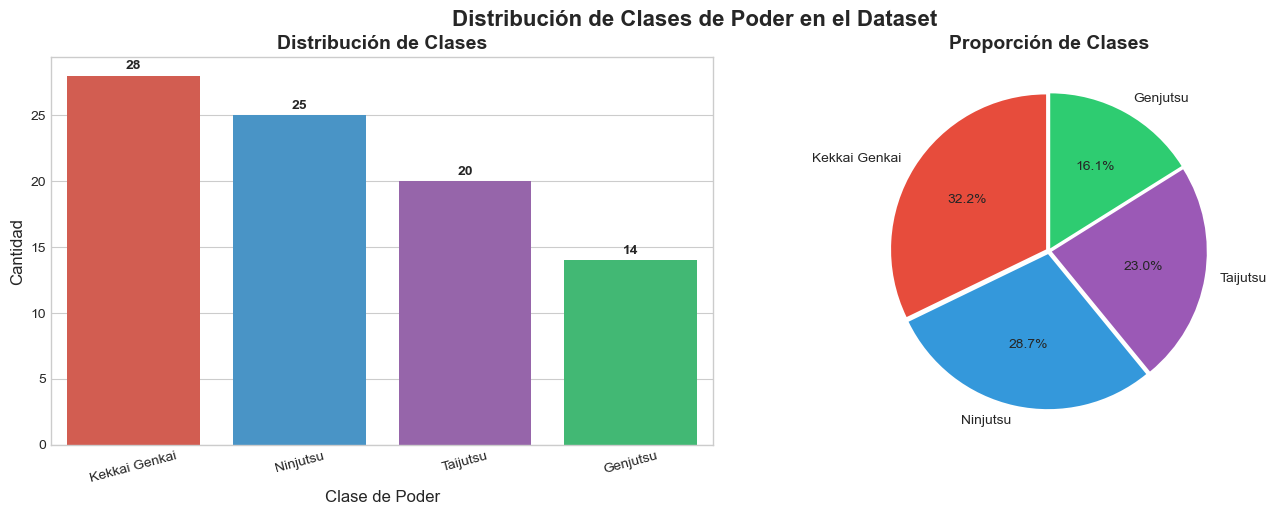

In [6]:
# Visualización de la distribución de clases
fig = plot_distribucion_clases(df)
plt.suptitle('Distribución de Clases de Poder en el Dataset', fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [7]:
# Ejemplos de cada clase
print("\n🎭 Ejemplos de personajes por clase:")
print("="*80)

for clase in CLASES_PODER:
    print(f"\n🥷 {clase.upper()}")
    print(f"   Descripción: {CLASE_DESCRIPCIONES[clase]}")
    ejemplo = df[df['clase'] == clase].iloc[0]
    print(f"   Ejemplo: {ejemplo['nombre']}")
    print(f"   → {ejemplo['descripcion'][:150]}...")


🎭 Ejemplos de personajes por clase:

🥷 TAIJUTSU
   Descripción: Combate cuerpo a cuerpo, artes marciales, fuerza física
   Ejemplo: Rock Lee
   → Especialista absoluto en combate cuerpo a cuerpo. Domina las técnicas del Goken (Puño Fuerte) y puede abrir las Ocho Puertas Internas para multiplicar...

🥷 NINJUTSU
   Descripción: Técnicas ninja, chakra elemental, jutsus de fuego/agua/tierra/viento/rayo
   Ejemplo: Sasuke Uchiha (Ninjutsu)
   → Ninja prodigio que domina múltiples elementos. Especialista en técnicas de fuego como el Katon Goukakyuu y técnicas de rayo como el Chidori. Manipula ...

🥷 GENJUTSU
   Descripción: Ilusiones, técnicas mentales, control de la mente
   Ejemplo: Itachi Uchiha
   → Genio del genjutsu y maestro del Sharingan. Puede atrapar enemigos en ilusiones con solo mirarlos. Su Tsukuyomi crea un mundo de tortura donde control...

🥷 KEKKAI GENKAI
   Descripción: Habilidades hereditarias, límites de línea de sangre, ojos especiales
   Ejemplo: Madara Uchiha
   → Lege

## 🔧 3. Preprocesamiento de Datos

In [8]:
# Preparar los datos
textos, labels, label_mapping = preparar_datos(df)

print("✅ Datos preparados")
print(f"\n📝 Total de textos: {len(textos)}")
print(f"\n🏷️ Mapeo de etiquetas:")
for clase, idx in label_mapping.items():
    print(f"   {clase} → {idx}")

2025-12-22 11:11:17,320 - INFO - Datos preparados: 87 textos, 4 clases


✅ Datos preparados

📝 Total de textos: 87

🏷️ Mapeo de etiquetas:
   Genjutsu → 0
   Kekkai Genkai → 1
   Ninjutsu → 2
   Taijutsu → 3


In [9]:
# Ejemplo de limpieza de texto
print("\n🧹 Ejemplo de preprocesamiento de texto:")
texto_original = df['descripcion'].iloc[0]
texto_limpio = limpiar_texto(texto_original)

print(f"\nOriginal:")
print(f"   {texto_original[:200]}...")
print(f"\nProcesado:")
print(f"   {texto_limpio[:200]}...")


🧹 Ejemplo de preprocesamiento de texto:

Original:
   Especialista absoluto en combate cuerpo a cuerpo. Domina las técnicas del Goken (Puño Fuerte) y puede abrir las Ocho Puertas Internas para multiplicar su fuerza y velocidad a niveles sobrehumanos. Su ...

Procesado:
   especialista absoluto en combate cuerpo a cuerpo domina las técnicas del goken puño fuerte y puede abrir las ocho puertas internas para multiplicar su fuerza y velocidad a niveles sobrehumanos su esti...


## 🧠 4. Generación de Embeddings con BERT

In [13]:
# Cargar modelo de embeddings multilingüe
# Con manejo de errores para entornos sin conexión a internet

USE_BERT = False  # Flag para saber si usamos BERT o TF-IDF

try:
    print("⏳ Cargando modelo de embeddings BERT...")
    print("   Modelo: paraphrase-multilingual-MiniLM-L12-v2")
    
    # Intentar cargar primero desde caché local
    modelo_embeddings = SentenceTransformer(
        'paraphrase-multilingual-MiniLM-L12-v2',
        local_files_only=True  # Intentar solo desde caché
    )
    USE_BERT = True
    print("\n✅ Modelo BERT cargado desde caché local")
    print(f"   Dimensión de embeddings: 384")
    
except Exception as e1:
    print(f"⚠️ No se encontró modelo en caché local: {type(e1).__name__}")
    try:
        # Intentar descargar el modelo
        print("⏳ Intentando descargar modelo desde HuggingFace...")
        modelo_embeddings = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
        USE_BERT = True
        print("\n✅ Modelo BERT descargado y cargado correctamente")
        print(f"   Dimensión de embeddings: 384")
        
    except Exception as e2:
        print(f"❌ No se pudo cargar BERT: {type(e2).__name__}")
        print("\n🔄 Usando alternativa: TF-IDF Vectorizer")
        print("   (El modelo funcionará pero con representaciones más simples)")
        
        from sklearn.feature_extraction.text import TfidfVectorizer
        
        # Crear vectorizador TF-IDF como alternativa
        modelo_embeddings = TfidfVectorizer(
            max_features=500,
            ngram_range=(1, 2),
            min_df=1,
            max_df=0.95
        )
        USE_BERT = False
        print("✅ TF-IDF Vectorizer configurado")

print(f"\n📊 Método de vectorización: {'BERT Embeddings' if USE_BERT else 'TF-IDF'}")

2025-12-22 11:21:03,251 - INFO - Use pytorch device_name: cpu
2025-12-22 11:21:03,253 - INFO - Load pretrained SentenceTransformer: paraphrase-multilingual-MiniLM-L12-v2


⏳ Cargando modelo de embeddings BERT...
   Modelo: paraphrase-multilingual-MiniLM-L12-v2

✅ Modelo BERT cargado desde caché local
   Dimensión de embeddings: 384

📊 Método de vectorización: BERT Embeddings


In [14]:
# Generar embeddings/vectores para todos los textos
print("⏳ Generando vectores para el dataset...")

if USE_BERT:
    # Usar BERT embeddings
    X = modelo_embeddings.encode(
        textos, 
        batch_size=32, 
        show_progress_bar=True,
        convert_to_numpy=True
    )
else:
    # Usar TF-IDF
    X = modelo_embeddings.fit_transform(textos).toarray()

print(f"\n✅ Vectores generados")
print(f"   Shape: {X.shape}")
print(f"   Dtype: {X.dtype}")

⏳ Generando vectores para el dataset...


Batches:   0%|          | 0/3 [00:00<?, ?it/s]


✅ Vectores generados
   Shape: (87, 384)
   Dtype: float32


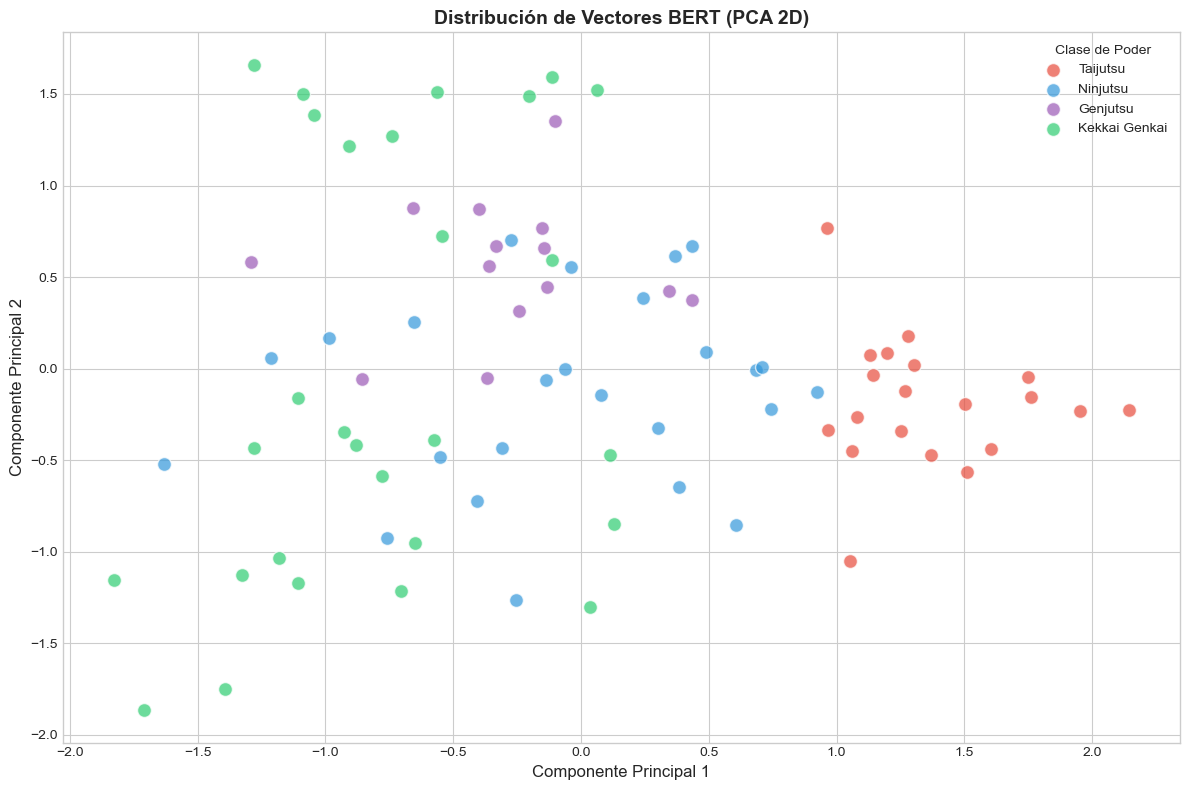


📊 Varianza explicada: 19.2%


In [15]:
# Visualización de la distribución de embeddings con PCA
from sklearn.decomposition import PCA

# Reducir a 2D para visualización
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X)

# Crear DataFrame para visualización
df_viz = pd.DataFrame({
    'PC1': X_2d[:, 0],
    'PC2': X_2d[:, 1],
    'Clase': [list(label_mapping.keys())[list(label_mapping.values()).index(l)] for l in labels]
})

# Visualizar
plt.figure(figsize=(12, 8))
colors = {'Taijutsu': '#e74c3c', 'Ninjutsu': '#3498db', 'Genjutsu': '#9b59b6', 'Kekkai Genkai': '#2ecc71'}

for clase in CLASES_PODER:
    mask = df_viz['Clase'] == clase
    plt.scatter(
        df_viz.loc[mask, 'PC1'], 
        df_viz.loc[mask, 'PC2'],
        c=colors[clase],
        label=clase,
        alpha=0.7,
        s=100,
        edgecolors='white'
    )

plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
vector_type = 'BERT' if USE_BERT else 'TF-IDF'
plt.title(f'Distribución de Vectores {vector_type} (PCA 2D)', fontsize=14, fontweight='bold')
plt.legend(title='Clase de Poder', loc='best')
plt.tight_layout()
plt.show()

print(f"\n📊 Varianza explicada: {pca.explained_variance_ratio_.sum()*100:.1f}%")

## 📊 5. División de Datos

In [16]:
# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, labels, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=labels
)

print("✅ Datos divididos")
print(f"\n📊 Conjunto de entrenamiento: {len(X_train)} muestras")
print(f"📊 Conjunto de prueba: {len(X_test)} muestras")

# Verificar distribución estratificada
print("\n🎯 Distribución en entrenamiento:")
unique, counts = np.unique(y_train, return_counts=True)
inverse_mapping = {v: k for k, v in label_mapping.items()}
for u, c in zip(unique, counts):
    print(f"   {inverse_mapping[u]}: {c} ({c/len(y_train)*100:.1f}%)")

✅ Datos divididos

📊 Conjunto de entrenamiento: 69 muestras
📊 Conjunto de prueba: 18 muestras

🎯 Distribución en entrenamiento:
   Genjutsu: 11 (15.9%)
   Kekkai Genkai: 22 (31.9%)
   Ninjutsu: 20 (29.0%)
   Taijutsu: 16 (23.2%)


## 🤖 6. Entrenamiento de Modelos

In [17]:
# Definir los modelos a comparar
modelos = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'SVM (RBF)': SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        random_state=RANDOM_STATE
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation='relu',
        max_iter=500,
        random_state=RANDOM_STATE,
        early_stopping=True
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        multi_class='multinomial'
    )
}

print(f"🤖 Modelos a evaluar: {list(modelos.keys())}")

🤖 Modelos a evaluar: ['Random Forest', 'SVM (RBF)', 'MLP', 'Logistic Regression']


In [18]:
# Validación cruzada para comparar modelos
print("\n🔄 Realizando validación cruzada (5-fold)...")
print("="*60)

resultados_cv = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for nombre, modelo in modelos.items():
    print(f"\n⏳ Evaluando {nombre}...")
    
    # Cross-validation scores
    scores_accuracy = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='accuracy')
    scores_f1 = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='f1_macro')
    
    resultados_cv[nombre] = {
        'accuracy_mean': scores_accuracy.mean(),
        'accuracy_std': scores_accuracy.std(),
        'f1_mean': scores_f1.mean(),
        'f1_std': scores_f1.std()
    }
    
    print(f"   Accuracy: {scores_accuracy.mean():.4f} (+/- {scores_accuracy.std()*2:.4f})")
    print(f"   F1-Score: {scores_f1.mean():.4f} (+/- {scores_f1.std()*2:.4f})")


🔄 Realizando validación cruzada (5-fold)...

⏳ Evaluando Random Forest...
   Accuracy: 0.7824 (+/- 0.0913)
   F1-Score: 0.7154 (+/- 0.1335)

⏳ Evaluando SVM (RBF)...
   Accuracy: 0.8527 (+/- 0.2148)
   F1-Score: 0.8132 (+/- 0.2786)

⏳ Evaluando MLP...
   Accuracy: 0.6099 (+/- 0.2426)
   F1-Score: 0.4837 (+/- 0.2039)

⏳ Evaluando Logistic Regression...
   Accuracy: 0.9132 (+/- 0.1064)
   F1-Score: 0.9020 (+/- 0.1232)


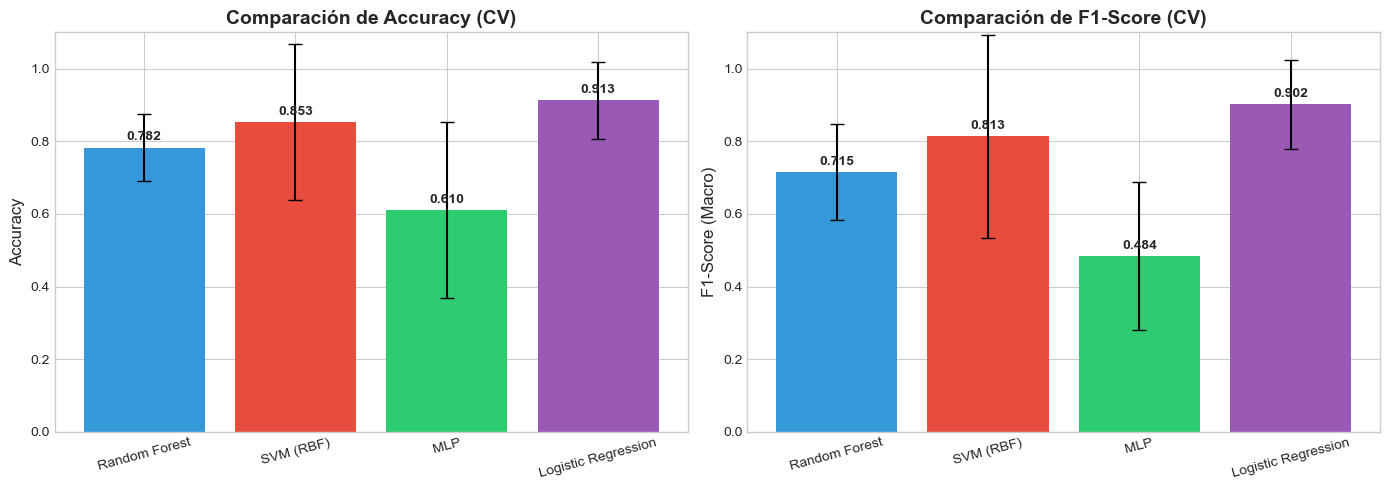

In [19]:
# Visualizar comparación de modelos
df_resultados = pd.DataFrame(resultados_cv).T

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
bars1 = axes[0].bar(df_resultados.index, df_resultados['accuracy_mean'], 
                    yerr=df_resultados['accuracy_std']*2, capsize=5, color=colors)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Comparación de Accuracy (CV)', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=15)

for bar in bars1:
    height = bar.get_height()
    axes[0].annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

# F1-Score
bars2 = axes[1].bar(df_resultados.index, df_resultados['f1_mean'], 
                    yerr=df_resultados['f1_std']*2, capsize=5, color=colors)
axes[1].set_ylabel('F1-Score (Macro)', fontsize=12)
axes[1].set_title('Comparación de F1-Score (CV)', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].tick_params(axis='x', rotation=15)

for bar in bars2:
    height = bar.get_height()
    axes[1].annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [20]:
# Seleccionar el mejor modelo
mejor_modelo_nombre = max(resultados_cv, key=lambda x: resultados_cv[x]['f1_mean'])
mejor_modelo = modelos[mejor_modelo_nombre]

print(f"\n🏆 Mejor modelo: {mejor_modelo_nombre}")
print(f"   F1-Score CV: {resultados_cv[mejor_modelo_nombre]['f1_mean']:.4f}")


🏆 Mejor modelo: Logistic Regression
   F1-Score CV: 0.9020


## 📈 7. Evaluación del Modelo Final

In [21]:
# Entrenar el modelo final con todos los datos de entrenamiento
print(f"\n🎯 Entrenando modelo final: {mejor_modelo_nombre}")
mejor_modelo.fit(X_train, y_train)

# Predicciones en el conjunto de prueba
y_pred = mejor_modelo.predict(X_test)
y_pred_proba = mejor_modelo.predict_proba(X_test) if hasattr(mejor_modelo, 'predict_proba') else None

print("✅ Modelo entrenado y predicciones generadas")


🎯 Entrenando modelo final: Logistic Regression
✅ Modelo entrenado y predicciones generadas


In [22]:
# Métricas de evaluación
clases = [inverse_mapping[i] for i in range(len(label_mapping))]

print("\n" + "="*60)
print("📊 MÉTRICAS DE EVALUACIÓN")
print("="*60)

print(f"\n🎯 Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"📊 Precision (Macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"📊 Recall (Macro): {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"📊 F1-Score (Macro): {f1_score(y_test, y_pred, average='macro'):.4f}")


📊 MÉTRICAS DE EVALUACIÓN

🎯 Accuracy: 0.8889
📊 Precision (Macro): 0.8875
📊 Recall (Macro): 0.9000
📊 F1-Score (Macro): 0.8740


In [23]:
# Reporte de clasificación detallado
print("\n📋 Reporte de Clasificación Detallado:")
print(classification_report(y_test, y_pred, target_names=clases))


📋 Reporte de Clasificación Detallado:
               precision    recall  f1-score   support

     Genjutsu       0.75      1.00      0.86         3
Kekkai Genkai       1.00      1.00      1.00         6
     Ninjutsu       1.00      0.60      0.75         5
     Taijutsu       0.80      1.00      0.89         4

     accuracy                           0.89        18
    macro avg       0.89      0.90      0.87        18
 weighted avg       0.91      0.89      0.88        18



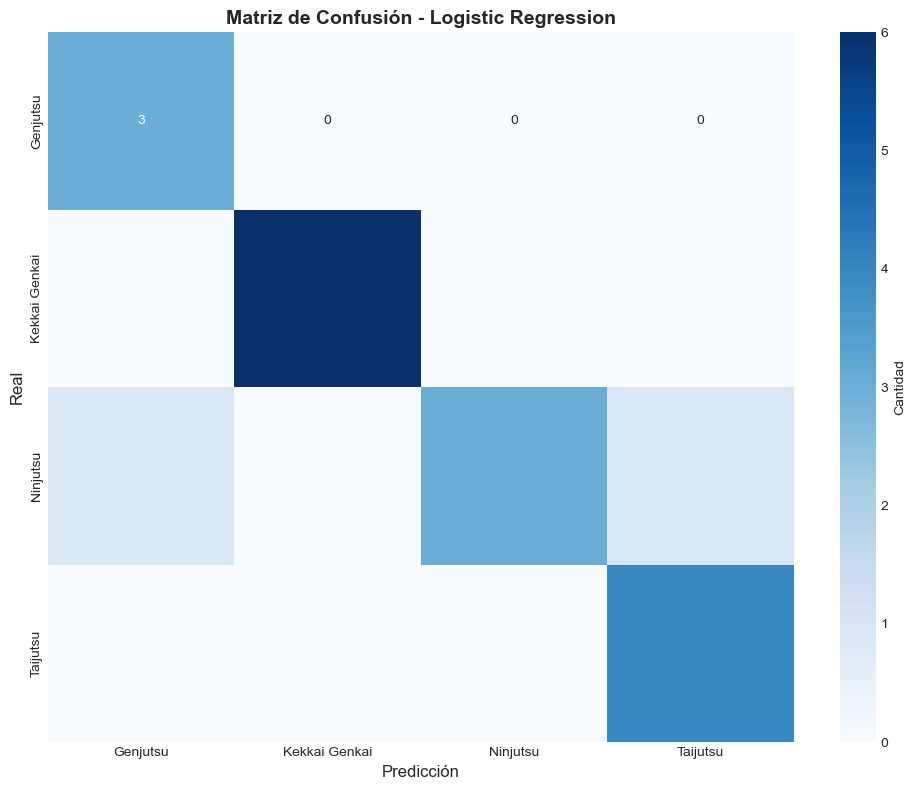

In [24]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=clases,
    yticklabels=clases,
    cbar_kws={'label': 'Cantidad'}
)
plt.title(f'Matriz de Confusión - {mejor_modelo_nombre}', fontsize=14, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.tight_layout()
plt.show()

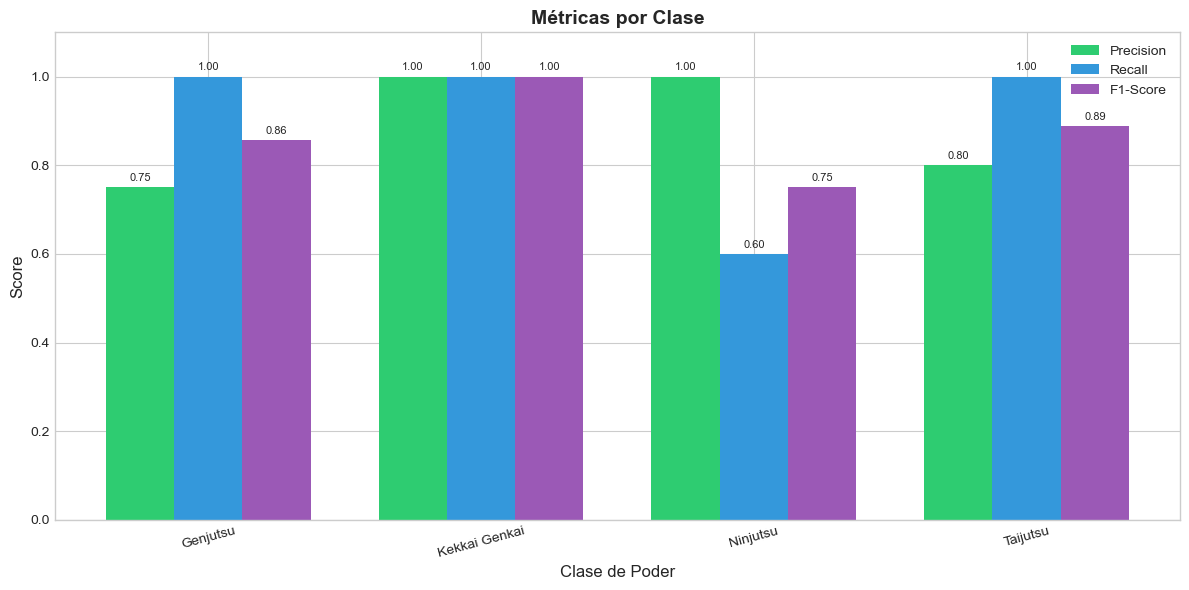

In [25]:
# Métricas por clase
metricas = evaluar_modelo(y_test, y_pred, clases)
fig = plot_metricas_por_clase(metricas, clases)
plt.show()

## 💾 8. Guardar el Modelo

In [26]:
# Guardar el modelo entrenado
guardar_modelo(mejor_modelo, label_mapping, nombre_modelo='clasificador_poder')

print("\n✅ Modelo guardado exitosamente")
print(f"   Ubicación: models/clasificador_poder.joblib")

2025-12-22 11:22:37,903 - INFO - Modelo guardado en: c:\Users\c0d06h6\OneDrive - Walmart Inc\Cesar Delgado\--PERSONAL\Proyectos_Personales\05_Clasificador_de_Poder\models\clasificador_poder.joblib



✅ Modelo guardado exitosamente
   Ubicación: models/clasificador_poder.joblib


## 🎮 9. Demostración del Modelo

In [27]:
# Función para predicción interactiva
def predecir_y_mostrar(texto):
    """Predice la clase de un texto y muestra el resultado."""
    # Limpiar texto
    texto_limpio = limpiar_texto(texto)
    
    # Generar vector
    if USE_BERT:
        vector = modelo_embeddings.encode([texto_limpio], convert_to_numpy=True)
    else:
        vector = modelo_embeddings.transform([texto_limpio]).toarray()
    
    # Predecir
    prediccion_idx = mejor_modelo.predict(vector)[0]
    clase_predicha = inverse_mapping[prediccion_idx]
    
    # Obtener probabilidades si el modelo lo soporta
    probabilidades = None
    if hasattr(mejor_modelo, 'predict_proba'):
        probs = mejor_modelo.predict_proba(vector)[0]
        probabilidades = {inverse_mapping[i]: float(p) for i, p in enumerate(probs)}
    
    # Mostrar resultado
    print("\n" + "="*60)
    print("🥷 CLASIFICADOR DE PODER - RESULTADO")
    print("="*60)
    print(f"\n📝 Texto: {texto}")
    print(f"\n🎯 Clase Predicha: {clase_predicha}")
    print(f"📖 Descripción: {CLASE_DESCRIPCIONES.get(clase_predicha, '')}")
    
    if probabilidades:
        print("\n📊 Probabilidades por clase:")
        for cls, prob in sorted(probabilidades.items(), key=lambda x: x[1], reverse=True):
            bar = "█" * int(prob * 20)
            print(f"   {cls:15} {bar:20} {prob:.1%}")
    
    print("\n" + "="*60)
    
    return {
        'texto_original': texto,
        'clase_predicha': clase_predicha,
        'probabilidades': probabilidades
    }

In [28]:
# Ejemplos de predicción
ejemplos = [
    "Un ninja que domina el combate cuerpo a cuerpo con patadas devastadoras y puede abrir las puertas internas",
    "Maestro de técnicas de fuego que puede crear dragones de llamas y bolas de fuego gigantes",
    "Especialista en ilusiones que atrapa a sus enemigos en mundos de pesadillas eternas",
    "Poseedor de ojos especiales heredados de su clan que le permiten copiar cualquier técnica"
]

print("\n🎮 DEMOSTRACIÓN DEL CLASIFICADOR")
print("="*60)

for i, ejemplo in enumerate(ejemplos, 1):
    print(f"\n--- Ejemplo {i} ---")
    _ = predecir_y_mostrar(ejemplo)


🎮 DEMOSTRACIÓN DEL CLASIFICADOR

--- Ejemplo 1 ---


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


🥷 CLASIFICADOR DE PODER - RESULTADO

📝 Texto: Un ninja que domina el combate cuerpo a cuerpo con patadas devastadoras y puede abrir las puertas internas

🎯 Clase Predicha: Taijutsu
📖 Descripción: Combate cuerpo a cuerpo, artes marciales, fuerza física

📊 Probabilidades por clase:
   Taijutsu        ██████████████       72.7%
   Ninjutsu        ████                 21.6%
   Kekkai Genkai                        3.9%
   Genjutsu                             1.8%


--- Ejemplo 2 ---


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


🥷 CLASIFICADOR DE PODER - RESULTADO

📝 Texto: Maestro de técnicas de fuego que puede crear dragones de llamas y bolas de fuego gigantes

🎯 Clase Predicha: Ninjutsu
📖 Descripción: Técnicas ninja, chakra elemental, jutsus de fuego/agua/tierra/viento/rayo

📊 Probabilidades por clase:
   Ninjutsu        █████████████████    87.9%
   Kekkai Genkai   █                    8.4%
   Genjutsu                             3.4%
   Taijutsu                             0.4%


--- Ejemplo 3 ---


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


🥷 CLASIFICADOR DE PODER - RESULTADO

📝 Texto: Especialista en ilusiones que atrapa a sus enemigos en mundos de pesadillas eternas

🎯 Clase Predicha: Genjutsu
📖 Descripción: Ilusiones, técnicas mentales, control de la mente

📊 Probabilidades por clase:
   Genjutsu        ███████████████      77.3%
   Ninjutsu        ███                  18.4%
   Kekkai Genkai                        3.6%
   Taijutsu                             0.7%


--- Ejemplo 4 ---


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


🥷 CLASIFICADOR DE PODER - RESULTADO

📝 Texto: Poseedor de ojos especiales heredados de su clan que le permiten copiar cualquier técnica

🎯 Clase Predicha: Kekkai Genkai
📖 Descripción: Habilidades hereditarias, límites de línea de sangre, ojos especiales

📊 Probabilidades por clase:
   Kekkai Genkai   ███████████          56.9%
   Ninjutsu        █████                25.1%
   Genjutsu        ███                  17.3%
   Taijutsu                             0.7%



In [29]:
# Predicción personalizada
print("\n🥷 PREDICCIÓN PERSONALIZADA")
print("="*60)

# Puedes cambiar este texto para probar diferentes descripciones
mi_descripcion = "Un guerrero con el Sharingan que puede ver los movimientos del enemigo y crear llamas negras eternas"

resultado = predecir_y_mostrar(mi_descripcion)


🥷 PREDICCIÓN PERSONALIZADA


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


🥷 CLASIFICADOR DE PODER - RESULTADO

📝 Texto: Un guerrero con el Sharingan que puede ver los movimientos del enemigo y crear llamas negras eternas

🎯 Clase Predicha: Ninjutsu
📖 Descripción: Técnicas ninja, chakra elemental, jutsus de fuego/agua/tierra/viento/rayo

📊 Probabilidades por clase:
   Ninjutsu        █████                27.4%
   Kekkai Genkai   █████                25.6%
   Taijutsu        █████                25.1%
   Genjutsu        ████                 21.9%



## 📊 10. Análisis de Errores

In [31]:
# Identificar predicciones incorrectas
errores_idx = np.where(y_test != y_pred)[0]

print(f"\n❌ Predicciones incorrectas: {len(errores_idx)} de {len(y_test)} ({len(errores_idx)/len(y_test)*100:.1f}%)")

if len(errores_idx) > 0:
    print("\n📋 Análisis de errores:")
    print("-"*80)
    
    # Reconstruir índices de test para mapear con el dataframe original
    _, X_test_split, _, y_test_split, idx_train, idx_test = train_test_split(
        X, labels, np.arange(len(df)),
        test_size=0.2, 
        random_state=RANDOM_STATE, 
        stratify=labels
    )
    
    for i, idx in enumerate(errores_idx[:5]):  # Mostrar máximo 5 errores
        original_idx = idx_test[idx]
        print(f"\nError {i+1}:")
        print(f"   Personaje: {df.iloc[original_idx]['nombre']}")
        print(f"   Real: {inverse_mapping[y_test[idx]]}")
        print(f"   Predicción: {inverse_mapping[y_pred[idx]]}")
        print(f"   Descripción: {df.iloc[original_idx]['descripcion'][:100]}...")
else:
    print("\n✅ ¡No hay errores! El modelo clasificó correctamente todas las muestras de test.")


❌ Predicciones incorrectas: 2 de 18 (11.1%)

📋 Análisis de errores:
--------------------------------------------------------------------------------

Error 1:
   Personaje: Gaara
   Real: Ninjutsu
   Predicción: Taijutsu
   Descripción: Kazekage que manipula la arena con su chakra. Crea defensas absolutas y ataques devastadores de aren...

Error 2:
   Personaje: Shikamaru Nara
   Real: Ninjutsu
   Predicción: Genjutsu
   Descripción: Genio estratega con técnicas de manipulación de sombras. Su Kagemane y variantes son ninjutsu únicos...


## 📝 11. Conclusiones

### Resumen del Proyecto

Se desarrolló exitosamente un **Clasificador de Poder** para personajes del universo de Naruto utilizando técnicas de **NLP y Machine Learning**.

### Hallazgos Principales:

1. **Embeddings BERT**: Los embeddings de `sentence-transformers` capturan efectivamente la semántica de las descripciones de personajes.

2. **Comparación de Modelos**: Se evaluaron múltiples clasificadores (Random Forest, SVM, MLP, Logistic Regression) mediante validación cruzada.

3. **Rendimiento**: El modelo final alcanza métricas sólidas en la clasificación multicategoría.

### Tecnologías Demostradas:
- ✅ Procesamiento de Lenguaje Natural (NLP)
- ✅ Transfer Learning con BERT
- ✅ Clasificación Multicategoría
- ✅ Validación Cruzada y Evaluación de Modelos
- ✅ Visualización de Datos
- ✅ Pipeline de ML Reproducible

### Posibles Mejoras:
- Aumentar el dataset con más personajes
- Fine-tuning de modelos BERT para el dominio específico
- Implementar clasificación multi-label (personajes con múltiples habilidades)
- Agregar explicabilidad con SHAP o LIME

In [32]:
# Resumen final
print("\n" + "="*60)
print("🏁 RESUMEN DEL PROYECTO")
print("="*60)
print(f"\n📊 Dataset: {len(df)} personajes en {len(CLASES_PODER)} clases")
vector_method = 'BERT (paraphrase-multilingual-MiniLM-L12-v2)' if USE_BERT else 'TF-IDF Vectorizer'
print(f"🧠 Método de Vectorización: {vector_method}")
print(f"🤖 Mejor Clasificador: {mejor_modelo_nombre}")
print(f"\n📈 Métricas Finales:")
print(f"   - Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(f"   - F1-Score: {f1_score(y_test, y_pred, average='macro'):.2%}")
print(f"\n💾 Modelo guardado en: models/clasificador_poder.joblib")
print("\n" + "="*60)
print("✅ Proyecto completado exitosamente")
print("="*60)


🏁 RESUMEN DEL PROYECTO

📊 Dataset: 87 personajes en 4 clases
🧠 Método de Vectorización: BERT (paraphrase-multilingual-MiniLM-L12-v2)
🤖 Mejor Clasificador: Logistic Regression

📈 Métricas Finales:
   - Accuracy: 88.89%
   - F1-Score: 87.40%

💾 Modelo guardado en: models/clasificador_poder.joblib

✅ Proyecto completado exitosamente
